In [1]:
#Importar los datos
import pandas as pd
from prophet import Prophet

#Cargar los datos
df = pd.read_csv('https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv')
df.head

<bound method NDFrame.head of               ds          y
0     2007-12-10   9.590761
1     2007-12-11   8.519590
2     2007-12-12   8.183677
3     2007-12-13   8.072467
4     2007-12-14   7.893572
...          ...        ...
2900  2016-01-16   7.817223
2901  2016-01-17   9.273878
2902  2016-01-18  10.333775
2903  2016-01-19   9.125871
2904  2016-01-20   8.891374

[2905 rows x 2 columns]>

In [2]:
#Creación del modelo sin conocer aun nada de nuestros datos
m = Prophet()

#Entrenamiento del modelo con los datos, inicialmente y para este caso el dataframe debe tener dos columnas obligatoriamente donde "ds" = fecha y "y" = valor a predecir
m.fit(df)
#Al ejecutar el .fit() se analiza:
#Tendencia global, patrones repetidos (semana, año), ajusta parametros estadisticos, aprende cómo evoluciona la serie temporal
#

16:22:45 - cmdstanpy - INFO - Chain [1] start processing
16:22:45 - cmdstanpy - INFO - Chain [1] done processing


In [3]:
#Ahora se realizan predicciones en un marco de datos con una columna ds (fechas para las cuales se debe hacer una predicción).
#Se puede obtener un marco de datos adecuado
#Para que el modelo prediga se le debe dar una tabla con fechas ya que prophet necesita saber ¿Para qué fechas quiere que se haga la predicción?
#La tabla solamente necesita una columna llamada "ds"
future = m.make_future_dataframe(periods=365)
#Lo anterior es un marco de datos en donde crea 365 dias hacia el futuro despues de la ultima fecha de mis datos
#Igualmente tiene las fechas pasadas para luego poder validar.
future.tail() #Muestra las últimas fechas gneradas

,ds
3265,2017-01-15
3266,2017-01-16
3267,2017-01-17
3268,2017-01-18
3269,2017-01-19


In [4]:
#Predit, el metodo usa lo qe aprendio durante el fit para calcular predicciones.
#El metodo toma el dataframe future y para cada fecha calcula una predición, en donde yhat es el  valor estiamdo por el modelo.
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

#Podemos interpretar lo siguiente: El modelo cree que el valor estará entre 110 y 135, siendo 120 la predicción central.

#Entonces predict() calcula: predicciones para fechas pasadas, predicciones para fechas futuras.
#Las predicciones en fechas pasadas permiten ver qué tan bien el modelo reproduce los datos históricos.

,ds,yhat,yhat_lower,yhat_upper
3265,2017-01-15,8.206966,7.451682,8.876754
3266,2017-01-16,8.531961,7.772075,9.222519
3267,2017-01-17,8.319378,7.556825,9.038110
3268,2017-01-18,8.151994,7.433283,8.874144
3269,2017-01-19,8.163910,7.418200,8.929923


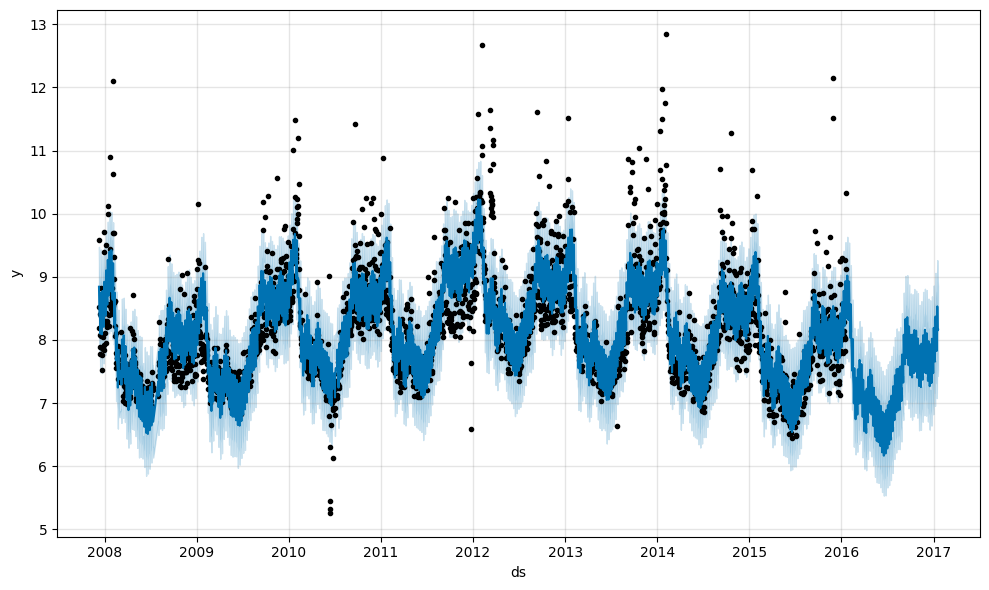

In [11]:
fig1 = m.plot(forecast)

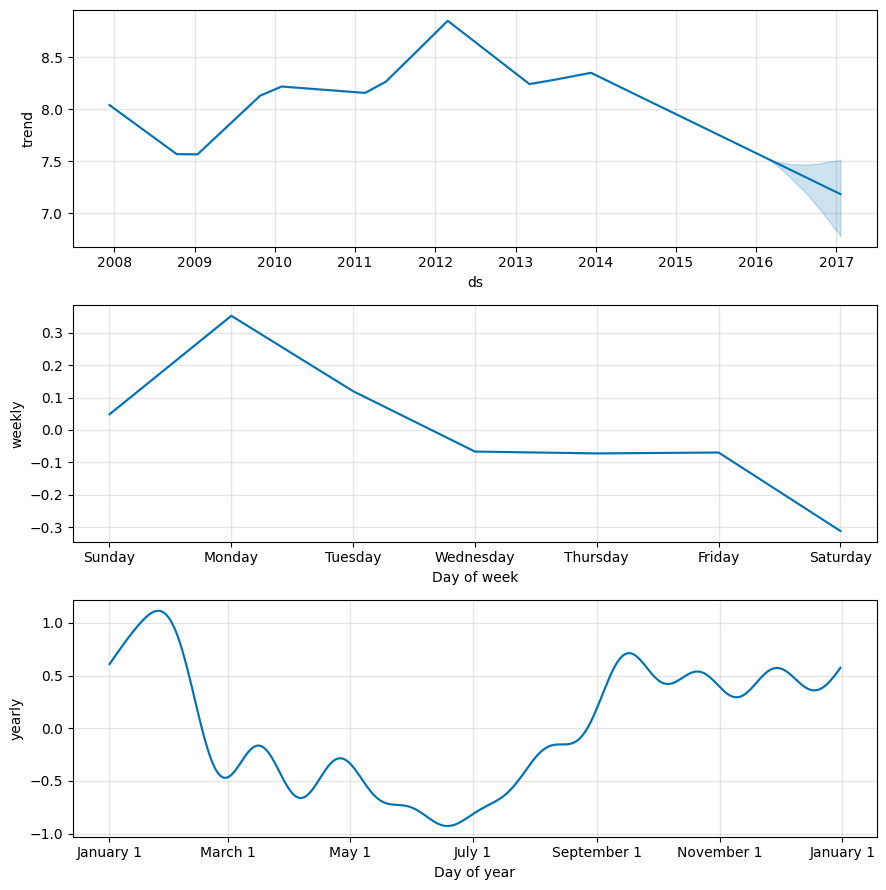

In [5]:
fig2 = m.plot_components(forecast)

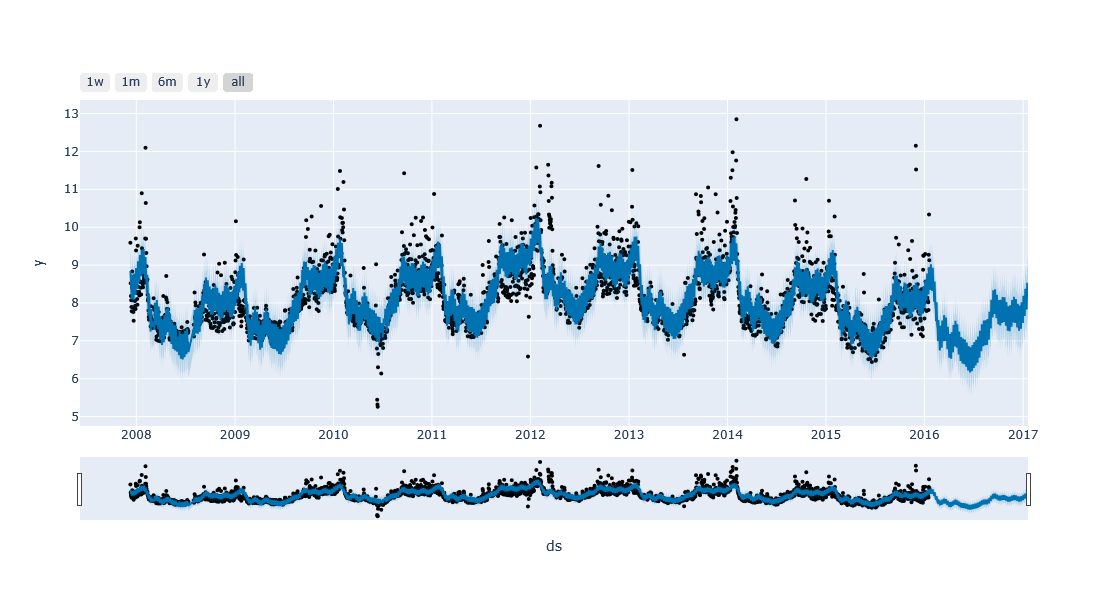

In [7]:
#Gráfico interactivo: se usa ploty 4.0
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(m, forecast)

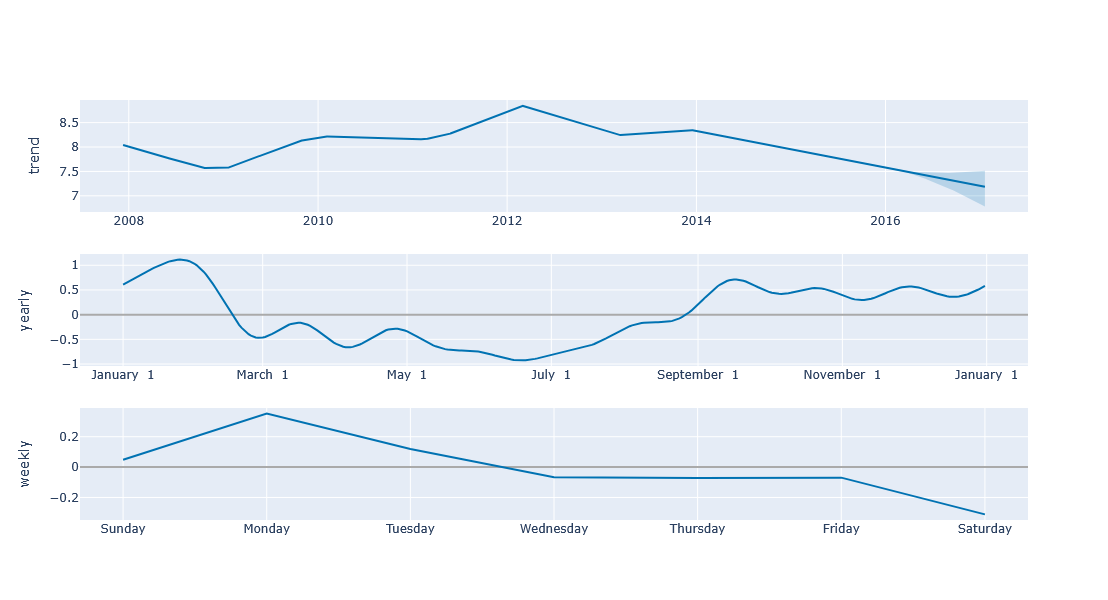

In [8]:
plot_components_plotly(m, forecast)